# SE4050 – Deep Learning: 4-Model Comparative Benchmark

### Automated Waste Classification System
This notebook provides a **single-cell, interactive evaluation pipeline** to compare all four project models side-by-side on any chosen test image:
1. **Custom CNN** *(Trained from scratch — 424K params)*
2. **ResNet50** *(Fine-tuned residual network — 23.85M params)*
3. **MobileNetV2** *(Fine-tuned inverted residuals — 2.27M params)*
4. **EfficientNetB0** *(Fine-tuned compound scaling — 4.06M params)*

**Instructions**: Run the cell below. A native Windows file picker will open allowing you to select any waste image (`.jpg`, `.png`, etc.). The cell will load the models, run inferences, display a side-by-side comparison dashboard, and output a detailed metrics table.

VERIFYING AND LOADING DEEP LEARNING MODELS
  [LOADING] Custom CNN      from: custom_cnn.keras...
  [READY]   Custom CNN      initialized.
  [LOADING] ResNet50        from: resnet50.keras...
  [READY]   ResNet50        initialized.
  [LOADING] MobileNetV2     from: mobilenetv2.keras...
  [READY]   MobileNetV2     initialized.
  [LOADING] EfficientNetB0  from: efficientnetb0.keras...
  [READY]   EfficientNetB0  initialized.

Opening file selection dialog... (Select a waste image)
[SELECTED] plastic.webp


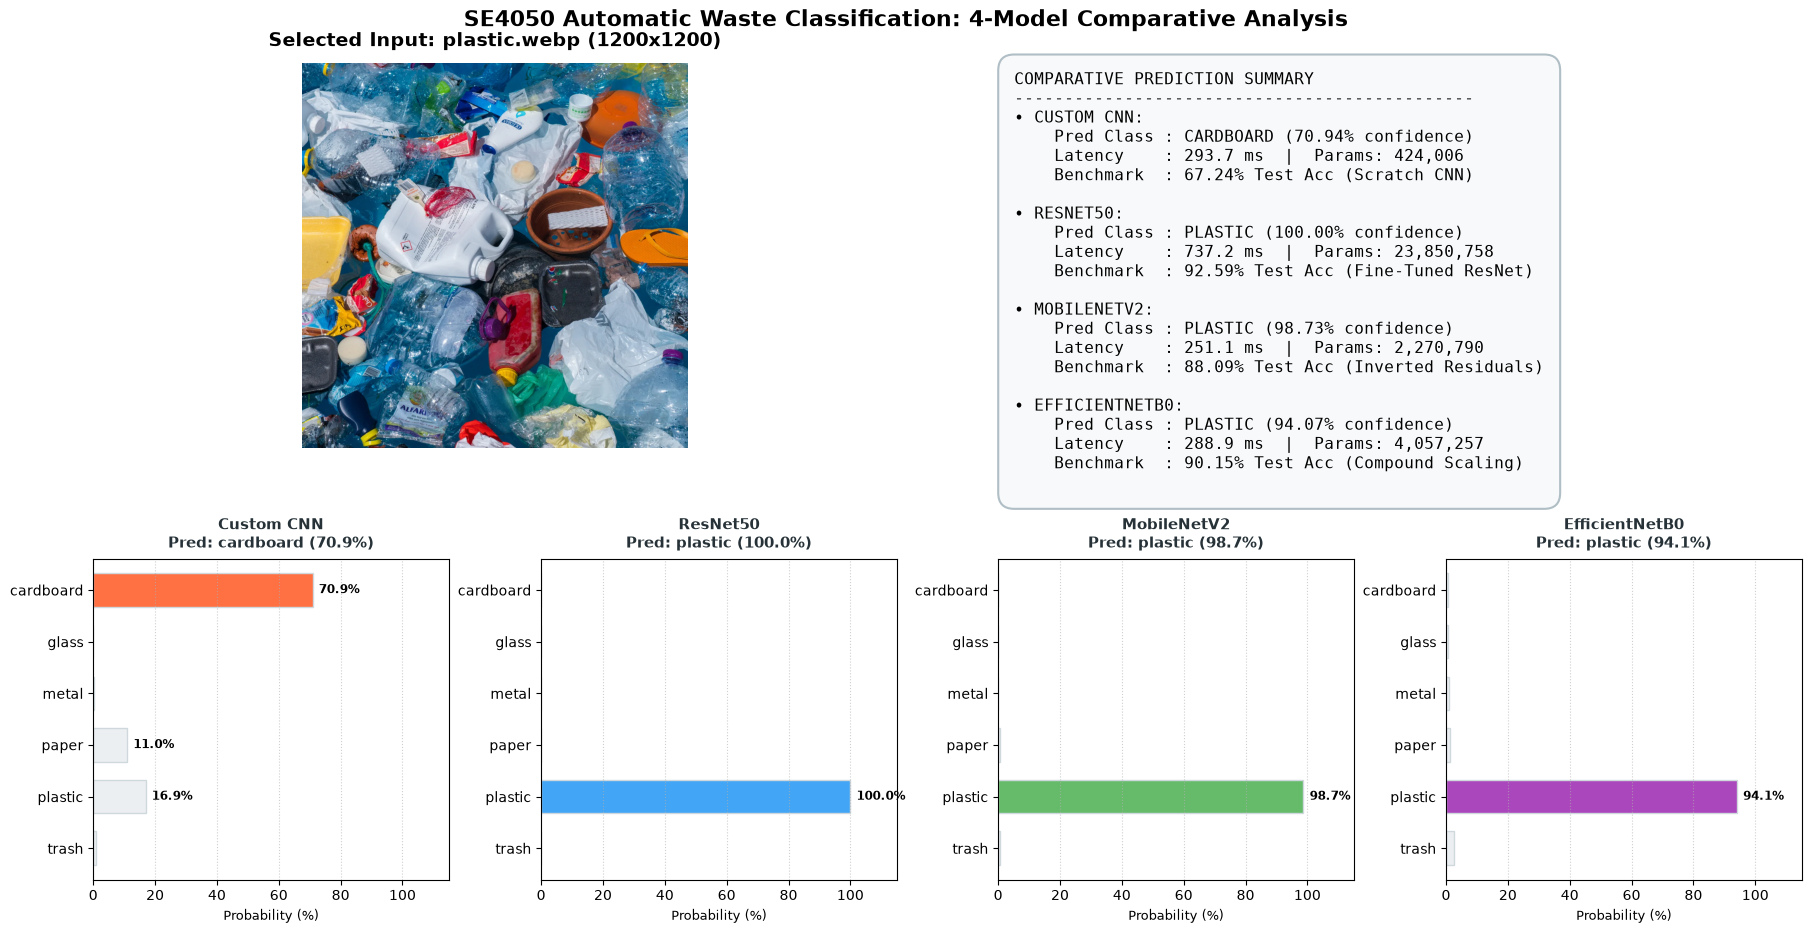


MODEL            | PREDICTION   | CONFIDENCE   | LATENCY (ms)   | PARAMS         | TEST ACCURACY 
Custom CNN       | cardboard    |      70.94% |        293.7 |        424,006 |         67.24%
ResNet50         | plastic      |     100.00% |        737.2 |     23,850,758 |         92.59%
MobileNetV2      | plastic      |      98.73% |        251.1 |      2,270,790 |         88.09%
EfficientNetB0   | plastic      |      94.07% |        288.9 |      4,057,257 |         90.15%



In [1]:
# ==============================================================================
# SE4050 – Multi-Model Waste Classification: Native File Picker & Comparison
# ==============================================================================
import os
import sys
import time
from pathlib import Path
import tkinter as tk
from tkinter import filedialog

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from PIL import Image

# ------------------------------------------------------------------------------
# 1. Dynamic Path Resolution
# ------------------------------------------------------------------------------
CURRENT_DIR = Path.cwd()
if (CURRENT_DIR / 'data').exists():
    PROJECT_ROOT = CURRENT_DIR
elif (CURRENT_DIR.parent / 'data').exists():
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

SEARCH_DIRS = [
    PROJECT_ROOT / 'app' / 'models',
    PROJECT_ROOT / 'src' / 'models',
    PROJECT_ROOT / 'models'
]

def locate_weights(candidate_names):
    for d in SEARCH_DIRS:
        if d.exists():
            for name in candidate_names:
                f = d / name
                if f.exists():
                    return f
    return None

# ------------------------------------------------------------------------------
# 2. Model Specifications & Preprocessing Configurations
# ------------------------------------------------------------------------------
MODEL_SPECS = {
    'Custom CNN': {
        'files': ['custom_cnn.keras', 'custom_cnn.h5'],
        'input_size': (224, 224),
        'preprocess': lambda x: x / 255.0,
        'params': '424,006',
        'test_acc': '67.24%',
        'paradigm': 'Scratch CNN',
        'bar_color': '#FF7043'
    },
    'ResNet50': {
        'files': ['resnet50.keras', 'resnet50_finetuned_best.keras'],
        'input_size': (256, 256),
        'preprocess': lambda x: tf.keras.applications.resnet50.preprocess_input(x.copy()),
        'params': '23,850,758',
        'test_acc': '92.59%',
        'paradigm': 'Fine-Tuned ResNet',
        'bar_color': '#42A5F5'
    },
    'MobileNetV2': {
        'files': ['mobilenetv2.keras', 'mobilenetv2_finetuned_best.keras'],
        'input_size': (224, 224),
        'preprocess': lambda x: tf.keras.applications.mobilenet_v2.preprocess_input(x.copy()),
        'params': '2,270,790',
        'test_acc': '88.09%',
        'paradigm': 'Inverted Residuals',
        'bar_color': '#66BB6A'
    },
    'EfficientNetB0': {
        'files': ['efficientnetb0.keras', 'efficientnetb0_final.keras'],
        'input_size': (224, 224),
        'preprocess': lambda x: tf.keras.applications.efficientnet.preprocess_input(x.copy()),
        'params': '4,057,257',
        'test_acc': '90.15%',
        'paradigm': 'Compound Scaling',
        'bar_color': '#AB47BC'
    }
}

CLASS_NAMES = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

# ------------------------------------------------------------------------------
# 3. In-Memory Model Cache (Load once across repeated cell runs)
# ------------------------------------------------------------------------------
if '_CACHED_MODELS' not in globals():
    _CACHED_MODELS = {}

print('='*70)
print('VERIFYING AND LOADING DEEP LEARNING MODELS')
print('='*70)
for m_name, spec in MODEL_SPECS.items():
    if m_name not in _CACHED_MODELS:
        fpath = locate_weights(spec['files'])
        if fpath:
            print(f'  [LOADING] {m_name:<15} from: {fpath.name}...')
            loaded = tf.keras.models.load_model(fpath)
            dummy_in = spec['preprocess'](np.zeros((1, *spec['input_size'], 3), dtype=np.float32))
            _ = loaded.predict(dummy_in, verbose=0)
            _CACHED_MODELS[m_name] = loaded
            print(f'  [READY]   {m_name:<15} initialized.')
        else:
            print(f'  [MISSING] {m_name:<15} weights file not found in search paths!')
    else:
        print(f'  [CACHED]  {m_name:<15} ready in memory.')

# ------------------------------------------------------------------------------
# 4. Native Windows File Picker Dialog
# ------------------------------------------------------------------------------
print('\nOpening file selection dialog... (Select a waste image)')
try:
    root = tk.Tk()
    root.withdraw()
    root.attributes('-topmost', True)
    root.lift()
    
    init_dir = str(PROJECT_ROOT / 'data' / 'raw')
    if not os.path.exists(init_dir):
        init_dir = str(PROJECT_ROOT / 'app' / 'examples')
    
    selected_image_path = filedialog.askopenfilename(
        title='Select Waste Image for 4-Model Comparison',
        initialdir=init_dir,
        filetypes=[
            ('Image Files', '*.jpg;*.jpeg;*.png;*.webp;*.bmp'),
            ('All Files', '*.*')
        ]
    )
    root.destroy()
except Exception as e:
    print(f'[NOTE] GUI file picker notice: {e}')
    selected_image_path = None

if not selected_image_path:
    example_candidates = list((PROJECT_ROOT / 'app' / 'examples').glob('*.jpg')) + \
                         list((PROJECT_ROOT / 'data' / 'raw').glob('**/*.jpg'))
    if example_candidates:
        selected_image_path = str(example_candidates[0])
        print(f'[INFO] No image selected. Defaulting to sample: {Path(selected_image_path).name}')
    else:
        raise FileNotFoundError('No image was selected and no sample images were found.')
else:
    print(f'[SELECTED] {Path(selected_image_path).name}')

# ------------------------------------------------------------------------------
# 5. Multi-Model Inference & Performance Measurement
# ------------------------------------------------------------------------------
raw_pil_image = Image.open(selected_image_path).convert('RGB')
w_orig, h_orig = raw_pil_image.size

inference_results = {}
for m_name, spec in MODEL_SPECS.items():
    mdl = _CACHED_MODELS.get(m_name)
    if mdl is None:
        continue
    
    resized_pil = raw_pil_image.resize(spec['input_size'])
    arr = np.array(resized_pil, dtype=np.float32)
    batch_arr = np.expand_dims(arr, axis=0)
    preprocessed_tensor = spec['preprocess'](batch_arr)
    
    t0 = time.perf_counter()
    predictions = mdl.predict(preprocessed_tensor, verbose=0)[0]
    latency_ms = (time.perf_counter() - t0) * 1000.0
    
    best_idx = int(np.argmax(predictions))
    best_class = CLASS_NAMES[best_idx]
    confidence_pct = float(predictions[best_idx]) * 100.0
    
    inference_results[m_name] = {
        'pred_class': best_class,
        'confidence': confidence_pct,
        'latency_ms': latency_ms,
        'probabilities': predictions,
        'best_idx': best_idx,
        'spec': spec
    }

# ------------------------------------------------------------------------------
# 6. Visual Comparative Dashboard
# ------------------------------------------------------------------------------
fig = plt.figure(figsize=(18, 9), constrained_layout=True)
gs = fig.add_gridspec(2, 4, height_ratios=[1.2, 1.0])

ax_input = fig.add_subplot(gs[0, :2])
ax_input.imshow(raw_pil_image)
ax_input.set_title(f'Selected Input: {Path(selected_image_path).name} ({w_orig}x{h_orig})', 
                   fontsize=14, fontweight='bold', pad=12)
ax_input.axis('off')

ax_summary = fig.add_subplot(gs[0, 2:])
ax_summary.axis('off')

card_lines = [
    'COMPARATIVE PREDICTION SUMMARY',
    '-' * 46
]
for m_name, res in inference_results.items():
    card_lines.append(f"• {m_name.upper()}:")
    card_lines.append(f"    Pred Class : {res['pred_class'].upper()} ({res['confidence']:.2f}% confidence)")
    card_lines.append(f"    Latency    : {res['latency_ms']:.1f} ms  |  Params: {res['spec']['params']}")
    card_lines.append(f"    Benchmark  : {res['spec']['test_acc']} Test Acc ({res['spec']['paradigm']})\n")

ax_summary.text(0.02, 0.98, '\n'.join(card_lines), transform=ax_summary.transAxes,
                fontsize=11.5, verticalalignment='top', fontfamily='monospace',
                bbox=dict(boxstyle='round,pad=1.0', facecolor='#F8F9FA', edgecolor='#B0BEC5', linewidth=1.5))

for col_idx, (m_name, res) in enumerate(inference_results.items()):
    ax_bar = fig.add_subplot(gs[1, col_idx])
    y_indices = np.arange(len(CLASS_NAMES))
    
    colors = [res['spec']['bar_color'] if i == res['best_idx'] else '#ECEFF1' 
              for i in range(len(CLASS_NAMES))]
    bars = ax_bar.barh(y_indices, res['probabilities'] * 100.0, color=colors, height=0.65, edgecolor='#CFD8DC')
    
    ax_bar.set_yticks(y_indices)
    ax_bar.set_yticklabels(CLASS_NAMES, fontsize=10)
    ax_bar.invert_yaxis()
    ax_bar.set_xlim(0, 115)
    ax_bar.set_xlabel('Probability (%)', fontsize=9.5)
    ax_bar.set_title(f"{m_name}\nPred: {res['pred_class']} ({res['confidence']:.1f}%)", 
                     fontsize=11, fontweight='bold', color='#263238', pad=8)
    ax_bar.grid(axis='x', linestyle=':', alpha=0.6)
    
    for bar in bars:
        width = bar.get_width()
        if width > 5.0:
            ax_bar.text(width + 2, bar.get_y() + bar.get_height() / 2,
                        f'{width:.1f}%', va='center', ha='left', fontsize=8.5, fontweight='bold')

plt.suptitle('SE4050 Automatic Waste Classification: 4-Model Comparative Analysis', 
             fontsize=16, fontweight='bold', y=1.02)
plt.show()

# ------------------------------------------------------------------------------
# 7. Formatted Terminal Metrics Table
# ------------------------------------------------------------------------------
print('\n' + '='*96)
print(f"{'MODEL':<16} | {'PREDICTION':<12} | {'CONFIDENCE':<12} | {'LATENCY (ms)':<14} | {'PARAMS':<14} | {'TEST ACCURACY':<14}")
print('='*96)
for m_name, res in inference_results.items():
    print(f"{m_name:<16} | {res['pred_class']:<12} | {res['confidence']:>10.2f}% | {res['latency_ms']:>12.1f} | {res['spec']['params']:>14} | {res['spec']['test_acc']:>14}")
print('='*96 + '\n')
